# Smart Parking — Component Benchmark

Test từng thành phần AI riêng biệt, đo latency / accuracy / throughput.

### Components:
1. **PlateDetector** — YOLOv8n plate detection (data riêng)
2. **PlateOCR + Validator** — PaddleOCR recognition (data riêng, .txt ground truth)
3. **FaceEngine** — InsightFace detection + embedding (LFW dataset)
4. **ParkingDB** — pgvector cosine search (dùng embedding thật từ LFW)
5. **End-to-End Pipeline** — Full flow benchmark

In [1]:
import numpy as np
import cv2
import time
import os
import sys
import glob
import json
import logging
import random
from pathlib import Path
from collections import defaultdict, Counter

%matplotlib inline
import matplotlib
# matplotlib.use('Agg')  # Fix cho Jetson không có display
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator

plt.style.use('dark_background')
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.15,
    'font.size': 11,
})

C = {
    'green': '#22c55e', 'blue': '#3b82f6', 'yellow': '#eab308',
    'red': '#ef4444', 'purple': '#a855f7', 'cyan': '#06b6d4',
    'orange': '#f97316', 'pink': '#ec4899',
}

logging.basicConfig(level=logging.WARNING)
print('Imports OK')

Imports OK


In [2]:
PROJECT_DIR = Path('/home/somethink/parking_system')
sys.path.insert(0, str(PROJECT_DIR))

# ── 1) PLATE DETECTION DATA ──
DET_IMAGES_DIR = 'yolo_plate_data/images/val'
DET_LABELS_DIR = 'yolo_plate_data/labels/val'

# ── 2) PLATE RECOGNITION (OCR) DATA ──
OCR_DATA_DIR = '/home/somethink/parking_system/paddle_format' 

# ── 3) FACE DATA — tự download LFW ──
LFW_DIR = str(PROJECT_DIR / 'benchmark_data' / 'lfw_funneled')

# ── Model paths ──
PLATE_MODEL = "/home/somethink/parking_system/models/plate_yolov8n.engine"

# ── Benchmark params ──
N_WARMUP = 5
N_BENCH  = 100

# ── Validate paths ──
def check_dir(name, path):
    if not path:
        print(f'  ⚠️  {name}: CHƯA SET')
        return False
    p = Path(path)
    if p.is_dir():
        n = len(list(p.iterdir()))
        print(f'  ✅ {name}: {path} ({n} files)')
        return True
    print(f'  ❌ {name}: KHÔNG TỒN TẠI')
    return False

print('Checking paths:')
HAS_DET_IMG = check_dir('Det images', DET_IMAGES_DIR)
HAS_DET_LBL = check_dir('Det labels', DET_LABELS_DIR)
HAS_DET = HAS_DET_IMG and HAS_DET_LBL
HAS_OCR = check_dir('OCR data', OCR_DATA_DIR)
HAS_LFW = check_dir('LFW faces', LFW_DIR)
print(f'  {"✅" if os.path.exists(PLATE_MODEL) else "❌"} Plate model: {PLATE_MODEL}')

Checking paths:
  ✅ Det images: yolo_plate_data/images/val (1651 files)
  ✅ Det labels: yolo_plate_data/labels/val (1651 files)
  ✅ OCR data: /home/somethink/parking_system/paddle_format (3189 files)
  ✅ LFW faces: /home/somethink/parking_system/benchmark_data/lfw_funneled (5760 files)
  ✅ Plate model: /home/somethink/parking_system/models/plate_yolov8n.engine


In [3]:
def bench(func, n=N_BENCH, warmup=N_WARMUP, label=''):
    """Benchmark 1 function → dict latency stats."""
    for _ in range(warmup):
        func()
    times = []
    for _ in range(n):
        t0 = time.perf_counter()
        func()
        times.append((time.perf_counter() - t0) * 1000)
    arr = np.array(times)
    s = {
        'label': label, 'n': n,
        'mean': arr.mean(), 'std': arr.std(),
        'min': arr.min(), 'max': arr.max(),
        'p50': np.percentile(arr, 50),
        'p95': np.percentile(arr, 95),
        'p99': np.percentile(arr, 99),
        'fps': 1000.0 / arr.mean() if arr.mean() > 0 else 0,
        'raw': arr,
    }
    print(f'  {label:30s}  avg={s["mean"]:7.2f}ms  '
          f'p95={s["p95"]:7.2f}ms  fps={s["fps"]:6.1f}')
    return s

def iou_calc(a, b):
    x1=max(a[0],b[0]); y1=max(a[1],b[1])
    x2=min(a[2],b[2]); y2=min(a[3],b[3])
    inter = max(0,x2-x1)*max(0,y2-y1)
    union = (a[2]-a[0])*(a[3]-a[1])+(b[2]-b[0])*(b[3]-b[1])-inter
    return inter/max(union,1e-6)

def edit_distance(s1, s2):
    m, n = len(s1), len(s2)
    dp = [[0]*(n+1) for _ in range(m+1)]
    for i in range(m+1): dp[i][0] = i
    for j in range(n+1): dp[0][j] = j
    for i in range(1, m+1):
        for j in range(1, n+1):
            dp[i][j] = min(dp[i-1][j]+1, dp[i][j-1]+1,
                           dp[i-1][j-1]+(0 if s1[i-1]==s2[j-1] else 1))
    return dp[m][n]


def pad_to_square(img):
    """
    Pad ảnh về hình vuông (max dimension).
    TensorRT engine export 640x640 cố định — nếu truyền ảnh
    không vuông, ultralytics letterbox thành shape lệch (vd 416x640)
    → TRT reject. Pad trước để YOLO resize về đúng 640x640.
    """
    h, w = img.shape[:2]
    if h == w:
        return img
    size = max(h, w)
    padded = np.zeros((size, size, 3), dtype=np.uint8)
    padded[:h, :w] = img
    return padded

print('Helpers ready (with pad_to_square for TRT)')


Helpers ready (with pad_to_square for TRT)


---
## 1. PlateDetector — YOLOv8n Detection
**Data**: ảnh gốc (1 folder) + YOLO labels (folder riêng)  
**Đo**: latency theo resolution, accuracy (P/R/F1 @ IoU≥0.5)

In [4]:
from engine import PlateDetector

print('Loading PlateDetector...')
plate_det = PlateDetector(PLATE_MODEL, imgsz=640, conf=0.4, device=0)
print('Done.\n')

# ══════════════════════════════════════════════════════════════
# TensorRT engine export cố định 640x640.
# → Benchmark dùng ảnh vuông (synthetic) + ảnh thật (pad square)
# ══════════════════════════════════════════════════════════════

det_latency = []
print('=== Latency ===')

# 1) Pure inference — 640x640 (khớp TRT input, không resize overhead)
img_sq = np.random.randint(0, 255, (640, 640, 3), dtype=np.uint8)
s = bench(lambda: plate_det(img_sq), n=N_BENCH, label='Det 640x640 (synthetic)')
det_latency.append(s)

# 2) Ảnh thật từ dataset — pad to square trước khi gọi detector
if HAS_DET:
    real_paths = sorted(
        glob.glob(os.path.join(DET_IMAGES_DIR, '*.jpg')) +
        glob.glob(os.path.join(DET_IMAGES_DIR, '*.png'))
    )[:50]
    loaded = [cv2.imread(p) for p in real_paths if cv2.imread(p) is not None]
    loaded = [img for img in loaded if img is not None][:50]
    if loaded:
        h0, w0 = loaded[0].shape[:2]
        print(f'  Real images: {len(loaded)} loaded, sample={w0}x{h0}')
        idx = [0]
        def det_real():
            img = loaded[idx[0] % len(loaded)]
            idx[0] += 1
            return plate_det(pad_to_square(img))
        s = bench(det_real, n=min(N_BENCH, len(loaded)*3), label=f'Det real {w0}x{h0} (padded)')
        det_latency.append(s)
else:
    # Fallback: ảnh vuông lớn hơn (YOLO resize → 640x640)
    img_lg = np.random.randint(0, 255, (1280, 1280, 3), dtype=np.uint8)
    s = bench(lambda: plate_det(img_lg), n=N_BENCH, label='Det 1280x1280 (resize)')
    det_latency.append(s)


Loading PlateDetector...
Loading /home/somethink/parking_system/models/plate_yolov8n.engine for TensorRT inference...
[03/31/2026-21:58:55] [TRT] [I] Loaded engine size: 8 MiB
[03/31/2026-21:58:55] [TRT] [W] Using an engine plan file across different models of devices is not recommended and is likely to affect performance or even cause errors.
[03/31/2026-21:58:55] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +0, GPU +15, now: CPU 0, GPU 20 (MiB)
WARNING ⚠️ Metadata not found for 'model=/home/somethink/parking_system/models/plate_yolov8n.engine'
Done.

=== Latency ===
  Det 640x640 (synthetic)         avg=  21.09ms  p95=  22.96ms  fps=  47.4
  Real images: 50 loaded, sample=472x303
  Det real 472x303 (padded)       avg=  30.59ms  p95=  31.27ms  fps=  32.7


In [5]:
# ── Accuracy trên detection dataset ──

det_acc = None

if not HAS_DET:
    print('⚠️  SKIP — chưa set DET_IMAGES_DIR và/hoặc DET_LABELS_DIR')
    print('   Sửa ở cell [config] rồi chạy lại.')
else:
    # Tìm ảnh-label pairs
    all_imgs = sorted(
        glob.glob(os.path.join(DET_IMAGES_DIR, '*.jpg')) +
        glob.glob(os.path.join(DET_IMAGES_DIR, '*.jpeg')) +
        glob.glob(os.path.join(DET_IMAGES_DIR, '*.png'))
    )
    pairs = []
    for img_p in all_imgs:
        lbl_p = os.path.join(DET_LABELS_DIR, Path(img_p).stem + '.txt')
        if os.path.exists(lbl_p):
            pairs.append((img_p, lbl_p))
    
    if len(pairs) > 500:
        random.seed(42)
        pairs = random.sample(pairs, 500)
    
    print(f'Found {len(pairs)} image-label pairs')
    
    det_acc = {'tp':0, 'fp':0, 'fn':0, 'confs':[], 'n_dets':[], 'times_ms':[]}
    
    for img_p, lbl_p in pairs:
        img = cv2.imread(img_p)
        if img is None: continue
        h, w = img.shape[:2]
        
        t0 = time.perf_counter()
        dets = plate_det(pad_to_square(img))  # pad cho TRT 640x640
        det_acc['times_ms'].append((time.perf_counter()-t0)*1000)
        det_acc['n_dets'].append(len(dets))
        
        # Parse YOLO labels
        gt_boxes = []
        with open(lbl_p) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5: continue
                cx,cy,bw,bh = map(float, parts[1:5])
                gt_boxes.append((
                    int((cx-bw/2)*w), int((cy-bh/2)*h),
                    int((cx+bw/2)*w), int((cy+bh/2)*h)
                ))
        
        # Greedy match (IoU ≥ 0.5)
        matched = set()
        for det in sorted(dets, key=lambda d: d['conf'], reverse=True):
            det_acc['confs'].append(det['conf'])
            best_iou, best_gi = 0, -1
            for gi, gt in enumerate(gt_boxes):
                if gi in matched: continue
                v = iou_calc(det['bbox'], gt)
                if v > best_iou: best_iou, best_gi = v, gi
            if best_iou >= 0.5 and best_gi >= 0:
                det_acc['tp'] += 1; matched.add(best_gi)
            else:
                det_acc['fp'] += 1
        det_acc['fn'] += len(gt_boxes) - len(matched)
    
    tp,fp,fn = det_acc['tp'], det_acc['fp'], det_acc['fn']
    prec = tp/max(tp+fp,1); rec = tp/max(tp+fn,1)
    f1 = 2*prec*rec/max(prec+rec,1e-6)
    
    print(f'\n  TP={tp}  FP={fp}  FN={fn}')
    print(f'  Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}')
    if det_acc['times_ms']:
        print(f'  Avg inference: {np.mean(det_acc["times_ms"]):.1f}ms (real images)')

Found 500 image-label pairs

  TP=502  FP=3  FN=1
  Precision=0.9941  Recall=0.9980  F1=0.9960
  Avg inference: 28.9ms (real images)


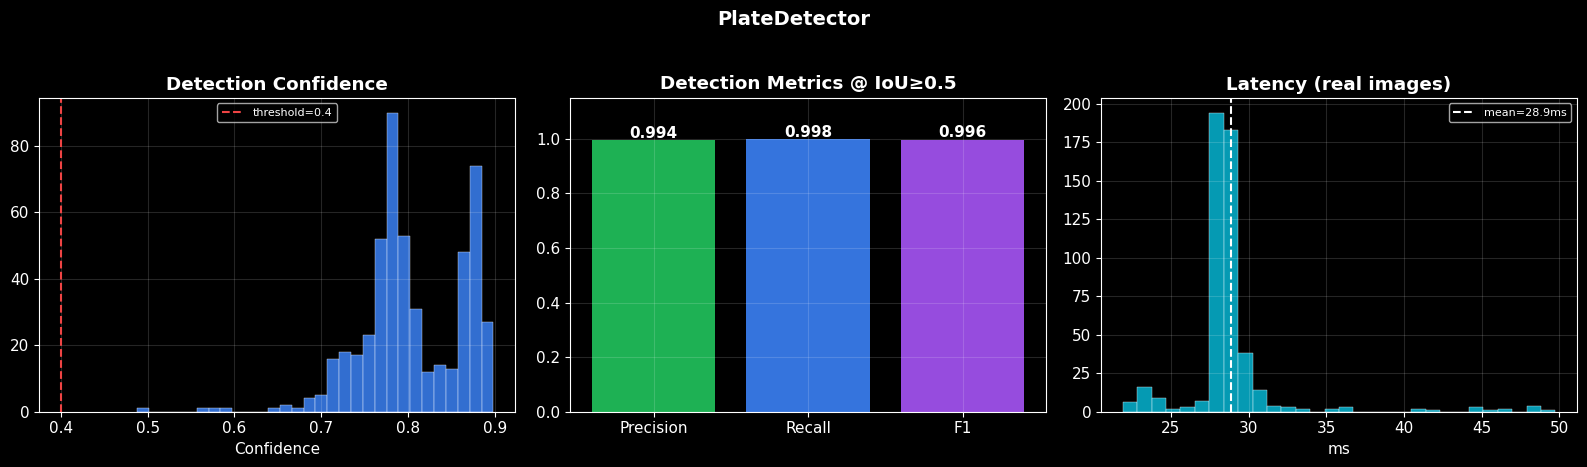

In [6]:
if det_acc and (det_acc['tp']+det_acc['fp']) > 0:
    tp,fp,fn = det_acc['tp'], det_acc['fp'], det_acc['fn']
    prec=tp/max(tp+fp,1); rec=tp/max(tp+fn,1)
    f1=2*prec*rec/max(prec+rec,1e-6)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    
    axes[0].hist(det_acc['confs'], bins=30, color=C['blue'], alpha=0.85, edgecolor='white', linewidth=0.3)
    axes[0].axvline(0.4, color=C['red'], linestyle='--', label='threshold=0.4')
    axes[0].set_title('Detection Confidence', fontweight='bold')
    axes[0].set_xlabel('Confidence'); axes[0].legend(fontsize=8)

    bars = axes[1].bar(['Precision','Recall','F1'], [prec,rec,f1],
                        color=[C['green'],C['blue'],C['purple']], alpha=0.9)
    for b,v in zip(bars,[prec,rec,f1]):
        axes[1].text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.3f}',
                     ha='center', fontsize=11, fontweight='bold')
    axes[1].set_ylim(0,1.15); axes[1].set_title('Detection Metrics @ IoU≥0.5', fontweight='bold')

    axes[2].hist(det_acc['times_ms'], bins=30, color=C['cyan'], alpha=0.85, edgecolor='white', linewidth=0.3)
    axes[2].axvline(np.mean(det_acc['times_ms']), color='white', linestyle='--',
                    label=f'mean={np.mean(det_acc["times_ms"]):.1f}ms')
    axes[2].set_title('Latency (real images)', fontweight='bold')
    axes[2].set_xlabel('ms'); axes[2].legend(fontsize=8)

    plt.suptitle('PlateDetector', fontsize=14, fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.savefig('/tmp/bench_det.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print('Không có detection accuracy data để vẽ')

---
## 2. PlateOCR + Validator
**Data**: folder chứa `*.jpg` + `*.txt` cùng tên (txt chứa text biển số)  
**Đo**: exact match, edit distance, validator pass rate, latency

In [9]:
from engine import PlateOCR
from main import PlateValidator

print('Loading PlateOCR...')
plate_ocr = PlateOCR(lang='en', use_gpu=True)
validator = PlateValidator()
print('Done.\n')

# ── Latency (synthetic crops) ──
ocr_latency = []
print('=== OCR Latency by Crop Size ===')
for name, (w,h) in [('80x24',(80,24)),('160x48',(160,48)),('320x96',(320,96)),('480x140',(480,140))]:
    crop = np.random.randint(0,255,(h,w,3), dtype=np.uint8)
    s = bench(lambda c=crop: plate_ocr(c), n=N_BENCH, label=f'OCR {name}')
    ocr_latency.append(s)

Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/somethink/.paddlex/official_models/PP-OCRv5_server_det`.


Loading PlateOCR...


Creating model: ('en_PP-OCRv5_mobile_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/somethink/.paddlex/official_models/en_PP-OCRv5_mobile_rec`.


Done.

=== OCR Latency by Crop Size ===
  OCR 80x24                       avg= 116.77ms  p95= 128.54ms  fps=   8.6
  OCR 160x48                      avg= 115.32ms  p95= 117.37ms  fps=   8.7
  OCR 320x96                      avg= 147.63ms  p95= 148.49ms  fps=   6.8
  OCR 480x140                     avg= 208.61ms  p95= 209.54ms  fps=   4.8


In [12]:
import shutil
from pathlib import Path
from statistics import median

SOURCE_ROOT = "yolo_plate_ocr_dataset"
OUTPUT_ROOT = "paddle_format"

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
COPY_IMAGE_IF_LABEL_MISSING = False   # True nếu muốn copy cả ảnh không có label
REC_GT_FILENAME = "rec_gt.txt"


def class_id_to_char(class_id: int) -> str:
    """
    0-9   -> '0'-'9'
    10-35 -> 'A'-'Z'
    """
    if 0 <= class_id <= 9:
        return str(class_id)
    if 10 <= class_id <= 35:
        return chr(ord("A") + class_id - 10)
    raise ValueError(f"class_id ngoài phạm vi hỗ trợ: {class_id}")


def parse_yolo_label_file(label_path: Path):
    """
    Trả về list object dạng:
    [
        {
            "char": "Z",
            "cx": 0.4,
            "cy": 0.28,
            "w": 0.18,
            "h": 0.39
        },
        ...
    ]
    """
    objects = []

    with open(label_path, "r", encoding="utf-8") as f:
        for line_num, raw_line in enumerate(f, start=1):
            line = raw_line.strip()
            if not line:
                continue

            parts = line.split()
            if len(parts) < 5:
                print(f"[WARN] {label_path} dòng {line_num}: không đủ 5 phần tử -> bỏ qua")
                continue

            try:
                class_id = int(parts[0])
                cx = float(parts[1])
                cy = float(parts[2])
                w = float(parts[3])
                h = float(parts[4])
                ch = class_id_to_char(class_id)
            except Exception as e:
                print(f"[WARN] {label_path} dòng {line_num}: parse lỗi -> {e}")
                continue

            objects.append({
                "char": ch,
                "cx": cx,
                "cy": cy,
                "w": w,
                "h": h,
            })

    return objects


def build_plate_text(objects):
    """
    Ghép các ký tự thành chuỗi biển số theo thứ tự đọc.

    Ý tưởng:
    - nếu chỉ có 1 hàng: sort theo cx
    - nếu có 2 hàng: tách theo khoảng cách y lớn nhất rồi
      sort từng hàng theo cx, ghép hàng trên trước hàng dưới
    """
    if not objects:
        return ""

    if len(objects) == 1:
        return objects[0]["char"]

    objs_sorted_y = sorted(objects, key=lambda o: o["cy"])
    ys = [o["cy"] for o in objs_sorted_y]
    hs = [o["h"] for o in objs_sorted_y]
    med_h = median(hs) if hs else 0.0

    # Tìm khoảng cách y lớn nhất giữa các ký tự sau khi sort theo cy
    gaps = []
    for i in range(len(ys) - 1):
        gaps.append(ys[i + 1] - ys[i])

    max_gap = max(gaps) if gaps else 0.0
    split_idx = gaps.index(max_gap) + 1 if gaps else None

    # Ngưỡng để coi là 2 hàng
    # med_h thường khá lớn vì bbox char cao, nên thêm ngưỡng cứng để ổn định hơn
    row_split_threshold = max(0.08, med_h * 0.6)

    if split_idx is not None and max_gap > row_split_threshold:
        top_row = objs_sorted_y[:split_idx]
        bottom_row = objs_sorted_y[split_idx:]

        top_row = sorted(top_row, key=lambda o: o["cx"])
        bottom_row = sorted(bottom_row, key=lambda o: o["cx"])

        plate_text = "".join(o["char"] for o in top_row + bottom_row)
    else:
        one_row = sorted(objects, key=lambda o: o["cx"])
        plate_text = "".join(o["char"] for o in one_row)

    return plate_text


def process_dataset(source_root: str, output_root: str):
    source_root = Path(source_root)
    output_root = Path(output_root)
    output_root.mkdir(parents=True, exist_ok=True)

    if not source_root.exists():
        raise FileNotFoundError(f"Không tìm thấy SOURCE_ROOT: {source_root}")

    image_paths = [
        p for p in source_root.rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS
    ]

    print(f"Tìm thấy {len(image_paths)} ảnh")

    rec_lines = []

    copied_count = 0
    ok_count = 0
    missing_label_count = 0
    skipped_count = 0
    empty_label_count = 0

    for img_path in image_paths:
        src_label_path = img_path.with_suffix(".txt")

        if not src_label_path.exists():
            missing_label_count += 1
            print(f"[WARN] Thiếu label: {img_path}")

            if COPY_IMAGE_IF_LABEL_MISSING:
                rel_img = img_path.relative_to(source_root)
                dst_img = output_root / rel_img
                dst_img.parent.mkdir(parents=True, exist_ok=True)
                shutil.copy2(img_path, dst_img)
                copied_count += 1
            else:
                skipped_count += 1
            continue

        objects = parse_yolo_label_file(src_label_path)
        if not objects:
            empty_label_count += 1
            print(f"[WARN] Label rỗng/không hợp lệ: {src_label_path}")
            skipped_count += 1
            continue

        plate_text = build_plate_text(objects)
        if not plate_text:
            empty_label_count += 1
            print(f"[WARN] Không ghép được text: {src_label_path}")
            skipped_count += 1
            continue

        # Copy ảnh sang output, giữ nguyên cấu trúc thư mục tương đối
        rel_img = img_path.relative_to(source_root)
        dst_img = output_root / rel_img
        dst_img.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(img_path, dst_img)
        copied_count += 1

        # Dòng label cho PaddleOCR recognition
        # dùng đường dẫn tương đối tính từ OUTPUT_ROOT
        rel_img_posix = rel_img.as_posix()
        rec_lines.append(f"{rel_img_posix}\t{plate_text}")
        ok_count += 1

    # Ghi file rec_gt.txt
    rec_gt_path = output_root / REC_GT_FILENAME
    with open(rec_gt_path, "w", encoding="utf-8") as f:
        if rec_lines:
            f.write("\n".join(rec_lines) + "\n")

    print("\n===== DONE =====")
    print(f"Ảnh đã copy          : {copied_count}")
    print(f"Mẫu OCR hợp lệ       : {ok_count}")
    print(f"Ảnh thiếu label      : {missing_label_count}")
    print(f"Label rỗng/lỗi       : {empty_label_count}")
    print(f"Bị skip              : {skipped_count}")
    print(f"File ground truth    : {rec_gt_path}")


if __name__ == "__main__":
    process_dataset(SOURCE_ROOT, OUTPUT_ROOT)

Tìm thấy 3188 ảnh

===== DONE =====
Ảnh đã copy          : 3188
Mẫu OCR hợp lệ       : 3188
Ảnh thiếu label      : 0
Label rỗng/lỗi       : 0
Bị skip              : 0
File ground truth    : paddle_format/rec_gt.txt


In [15]:
# ── OCR Accuracy ──
ocr_acc = None

if not HAS_OCR:
    print('⚠️  SKIP — chưa set OCR_DATA_DIR')
    print('   Sửa ở cell [config] rồi chạy lại.')
else:
    # Tìm pairs: ảnh + .txt cùng tên, CÙNG folder
    pairs = []
    with open(os.path.join(OCR_DATA_DIR, '0rec_gt.txt'), 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line or '\t' not in line:
                continue
            rel_img, gt = line.split('\t', 1)
            img_p = os.path.join(OCR_DATA_DIR, rel_img)
            if os.path.exists(img_p) and gt.strip():
                pairs.append((img_p, gt.strip()))
    
    if len(pairs) > 500:
        random.seed(42)
        pairs = random.sample(pairs, 500)
    
    print(f'Found {len(pairs)} image-label pairs\n')
    
    ocr_acc = {
        'exact': 0, 'validated_match': 0,
        'validator_pass_ocr': 0, 'validator_pass_gt': 0,
        'edit_dists': [], 'confs': [], 'times_ms': [],
        'details': [],
    }
    
    for img_p, gt_text in pairs:
        crop = cv2.imread(img_p)
        if crop is None or crop.size == 0: continue
        
        t0 = time.perf_counter()
        raw, conf = plate_ocr(crop)
        ocr_acc['times_ms'].append((time.perf_counter()-t0)*1000)
        ocr_acc['confs'].append(conf)
        
        # Clean cả 2 phía: bỏ dấu, uppercase
        ocr_c = raw.replace(' ','').replace('-','').replace('.','').upper()
        gt_c  = gt_text.replace(' ','').replace('-','').replace('.','').upper()
        
        exact = (ocr_c == gt_c) and len(ocr_c) > 0
        if exact: ocr_acc['exact'] += 1
        
        ocr_v = validator(raw)
        gt_v  = validator(gt_text)
        if ocr_v: ocr_acc['validator_pass_ocr'] += 1
        if gt_v:  ocr_acc['validator_pass_gt'] += 1
        if ocr_v and gt_v and ocr_v == gt_v:
            ocr_acc['validated_match'] += 1
        
        ed = edit_distance(ocr_c, gt_c)
        ocr_acc['edit_dists'].append(ed)
        
        ocr_acc['details'].append({
            'file': Path(img_p).name,
            'gt': gt_text, 'gt_clean': gt_c,
            'ocr_raw': raw, 'ocr_clean': ocr_c,
            'ocr_valid': ocr_v, 'gt_valid': gt_v,
            'exact': exact, 'ed': ed, 'conf': conf,
        })
    
    N = len(ocr_acc['details'])
    print(f'=== OCR Accuracy ({N} crops) ===')
    print(f'  Exact match (clean):  {ocr_acc["exact"]:4d}/{N}  ({100*ocr_acc["exact"]/max(N,1):.1f}%)')
    print(f'  Validated match:      {ocr_acc["validated_match"]:4d}/{N}  ({100*ocr_acc["validated_match"]/max(N,1):.1f}%)')
    print(f'  Validator pass (OCR): {ocr_acc["validator_pass_ocr"]:4d}/{N}  ({100*ocr_acc["validator_pass_ocr"]/max(N,1):.1f}%)')
    print(f'  Validator pass (GT):  {ocr_acc["validator_pass_gt"]:4d}/{N}  ({100*ocr_acc["validator_pass_gt"]/max(N,1):.1f}%)')
    ed_arr = np.array(ocr_acc['edit_dists'])
    print(f'  Edit distance:        mean={ed_arr.mean():.2f}  median={np.median(ed_arr):.0f}')
    print(f'  Avg latency:          {np.mean(ocr_acc["times_ms"]):.1f}ms')
    
    # Top errors
    errs = sorted([d for d in ocr_acc['details'] if not d['exact'] and d['gt_clean']],
                  key=lambda d: d['ed'], reverse=True)[:10]
    if errs:
        print(f'\n  ── Worst errors ──')
        for r in errs:
            print(f'    GT={r["gt_clean"]:15s}  OCR={r["ocr_clean"]:15s}  '
                  f'ed={r["ed"]}  conf={r["conf"]:.2f}  [{r["file"]}]')

Found 500 image-label pairs

=== OCR Accuracy (500 crops) ===
  Exact match (clean):   356/500  (71.2%)
  Validated match:        74/500  (14.8%)
  Validator pass (OCR):  244/500  (48.8%)
  Validator pass (GT):   337/500  (67.4%)
  Edit distance:        mean=3.10  median=0
  Avg latency:          691.8ms

  ── Worst errors ──
    GT=8B66512          OCR=65128B6CZDILYTRUCKBUSTRAILERNAHRADNISCHAFERWWWSASACZSYKORA  ed=55  conf=0.98  [iwt7133.jpg]
    GT=4B60620          OCR=4B60620CZAAAAUTOVYBÉR,KVALITAACENYPROKAZDÉHO!800110800  ed=47  conf=0.97  [iwt777.jpg]
    GT=8T43418          OCR=8T43418CZAUTOPOKORNYBRNOLESNAWWWRENAUITBRNOCIRENAULT  ed=45  conf=0.98  [iwt84.jpg]
    GT=B0L3403          OCR=3403BOL999841888TOTALNENIZKECENY!AUTODISKONTCZ  ed=43  conf=0.99  [iwt737.jpg]
    GT=BZN1065          OCR=1065BZN77248007,604477009HAUPTLYSONEKAUTOOPRAVNA  ed=43  conf=0.96  [iwt871.jpg]
    GT=2Z52689          OCR=26892Z5CZVSETINNIDRAINI857413177AUTODILYKMIKUS  ed=42  conf=0.95  [iwt734.jpg]
  

In [ ]:
if ocr_acc and ocr_acc['details']:
    N = len(ocr_acc['details'])
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1) Accuracy bars
    metrics = ['Exact\nMatch', 'Validated\nMatch', 'Validator\nPass (OCR)', 'Validator\nPass (GT)']
    vals = [ocr_acc['exact']/max(N,1), ocr_acc['validated_match']/max(N,1),
            ocr_acc['validator_pass_ocr']/max(N,1), ocr_acc['validator_pass_gt']/max(N,1)]
    bars = axes[0,0].bar(metrics, vals, color=[C['green'],C['blue'],C['cyan'],C['purple']], alpha=0.9)
    for b,v in zip(bars,vals):
        axes[0,0].text(b.get_x()+b.get_width()/2, v+0.01, f'{v*100:.1f}%',
                       ha='center', fontsize=10, fontweight='bold')
    axes[0,0].set_ylim(0,1.15); axes[0,0].set_title('OCR Accuracy', fontweight='bold')

    # 2) Edit distance
    ed_arr = np.array(ocr_acc['edit_dists'])
    axes[0,1].hist(ed_arr, bins=range(0, min(int(ed_arr.max())+2, 20)),
                   color=C['yellow'], alpha=0.85, edgecolor='white', linewidth=0.3)
    axes[0,1].axvline(ed_arr.mean(), color='white', linestyle='--', label=f'mean={ed_arr.mean():.2f}')
    axes[0,1].set_title('Edit Distance (0=perfect)', fontweight='bold')
    axes[0,1].xaxis.set_major_locator(MaxNLocator(integer=True)); axes[0,1].legend()

    # 3) Confidence: correct vs wrong
    ok_c = [d['conf'] for d in ocr_acc['details'] if d['exact']]
    bad_c = [d['conf'] for d in ocr_acc['details'] if not d['exact'] and d['conf']>0]
    if ok_c: axes[1,0].hist(ok_c, bins=20, color=C['green'], alpha=0.7,
                             label=f'Correct (n={len(ok_c)})', edgecolor='white', linewidth=0.3)
    if bad_c: axes[1,0].hist(bad_c, bins=20, color=C['red'], alpha=0.5,
                              label=f'Wrong (n={len(bad_c)})', edgecolor='white', linewidth=0.3)
    axes[1,0].set_title('Confidence: Correct vs Wrong', fontweight='bold')
    axes[1,0].set_xlabel('Confidence'); axes[1,0].legend(fontsize=9)

    # 4) Latency
    t_arr = np.array(ocr_acc['times_ms'])
    axes[1,1].hist(t_arr, bins=30, color=C['purple'], alpha=0.85, edgecolor='white', linewidth=0.3)
    axes[1,1].axvline(t_arr.mean(), color='white', linestyle='--', label=f'mean={t_arr.mean():.1f}ms')
    axes[1,1].axvline(np.percentile(t_arr,95), color=C['red'], linestyle=':', label=f'p95={np.percentile(t_arr,95):.1f}ms')
    axes[1,1].set_title('OCR Latency (real crops)', fontweight='bold')
    axes[1,1].set_xlabel('ms'); axes[1,1].legend(fontsize=8)

    plt.suptitle('PlateOCR + Validator', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('/tmp/bench_ocr.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print('Không có OCR data để vẽ')

---
## 3. FaceEngine — LFW Dataset
**Data**: LFW (Labeled Faces in the Wild) — ~13,000 ảnh mặt  
**Đo**: detection rate, same/diff person similarity, optimal threshold, latency

In [4]:
import os, glob, tarfile, urllib.request
from pathlib import Path
from collections import defaultdict

# ===== Paths =====
LFW_TGZ = str(PROJECT_DIR / 'benchmark_data' / 'lfw-funneled.tgz')
LFW_EXTRACT = str(PROJECT_DIR / 'benchmark_data')
LFW_ROOT = os.path.join(LFW_EXTRACT, 'lfw_funneled')

os.makedirs(LFW_EXTRACT, exist_ok=True)

# ===== Download URLs =====
LFW_URLS = [
    'https://ndownloader.figshare.com/files/5976015',   # mirror used by scikit-learn
    'http://vis-www.cs.umass.edu/lfw/lfw-funneled.tgz', # original source
]

def download_with_fallback(urls, dst):
    last_err = None
    for url in urls:
        try:
            print(f'Trying: {url}')
            urllib.request.urlretrieve(url, dst)
            print('Download OK')
            return url
        except Exception as e:
            print(f'Failed: {e}')
            last_err = e
            # xóa file lỗi / tải dở
            if os.path.exists(dst):
                try:
                    os.remove(dst)
                except:
                    pass
    raise RuntimeError(f'Cannot download LFW from any source. Last error: {last_err}')

# ===== Main =====
if os.path.isdir(LFW_ROOT) and len(os.listdir(LFW_ROOT)) > 100:
    print(f'✅ LFW exists: {LFW_ROOT}')
else:
    print('Downloading LFW...')
    if not os.path.exists(LFW_TGZ):
        used_url = download_with_fallback(LFW_URLS, LFW_TGZ)
        print(f'Used URL: {used_url}')
    else:
        print(f'Found existing archive: {LFW_TGZ}')

    print('Extracting...')
    with tarfile.open(LFW_TGZ, 'r:gz') as tar:
        tar.extractall(LFW_EXTRACT)
    print('Done.')

lfw_images = sorted(glob.glob(os.path.join(LFW_ROOT, '*', '*.jpg')))
print(f'LFW images: {len(lfw_images)}')

# Người có >= 2 ảnh
person_imgs = defaultdict(list)
for p in lfw_images:
    person_imgs[Path(p).parent.name].append(p)

multi = {k: v for k, v in person_imgs.items() if len(v) >= 2}
print(f'Persons with >= 2 images: {len(multi)}')

✅ LFW exists: /home/somethink/parking_system/benchmark_data/lfw_funneled
LFW images: 13233
Persons with >= 2 images: 1680


In [5]:
from engine import FaceEngine

print('Loading FaceEngine...')
face_eng = FaceEngine(model_pack='buffalo_sc', det_size=(640, 640))
print('Done.\n')

face_latency = []
print('=== FaceEngine Latency ===')
for name, (w,h) in [('640x480',(640,480)), ('1280x720',(1280,720))]:
    img = np.random.randint(0,255,(h,w,3), dtype=np.uint8)
    s = bench(lambda img=img: face_eng(img), n=N_BENCH, label=f'Face {name}')
    face_latency.append(s)

Loading FaceEngine...


/home/somethink/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Applied providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}, 'TensorrtExecutionProvider': {'trt_load_user_initializer': '0', 'trt_op_types_to_exclude': '', 'trt_external_data_bytestream': '0', 'trt_preview_feature

In [6]:
# ── Detection rate trên LFW ──
N_SAMPLE = 200
sample = random.sample(lfw_images, min(N_SAMPLE, len(lfw_images)))

face_acc = {'detected':0, 'no_face':0, 'multi':0, 'confs':[], 'times_ms':[]}

for p in sample:
    img = cv2.imread(p)
    if img is None: continue
    t0 = time.perf_counter()
    faces = face_eng(img)
    face_acc['times_ms'].append((time.perf_counter()-t0)*1000)
    if len(faces)==0: face_acc['no_face']+=1
    elif len(faces)==1:
        face_acc['detected']+=1; face_acc['confs'].append(faces[0]['conf'])
    else:
        face_acc['multi']+=1; face_acc['confs'].append(max(f['conf'] for f in faces))

tot = face_acc['detected']+face_acc['no_face']+face_acc['multi']
print(f'=== Face Detection ({tot} images) ===')
print(f'  Detected: {face_acc["detected"]} ({100*face_acc["detected"]/max(tot,1):.1f}%)')
print(f'  No face:  {face_acc["no_face"]} ({100*face_acc["no_face"]/max(tot,1):.1f}%)')
print(f'  Multi:    {face_acc["multi"]}')

=== Face Detection (200 images) ===
  Detected: 163 (81.5%)
  No face:  1 (0.5%)
  Multi:    36


In [7]:
# ── Same vs Different person similarity ──
N_PAIRS = 100

def get_emb(path):
    img = cv2.imread(path)
    if img is None: return None
    faces = face_eng(img)
    return max(faces, key=lambda f: f['conf'])['embedding'] if faces else None

# Same person
same_sims = []
for name, imgs in list(multi.items()):
    if len(same_sims) >= N_PAIRS: break
    e1, e2 = get_emb(imgs[0]), get_emb(imgs[1])
    if e1 is not None and e2 is not None:
        same_sims.append(float(np.dot(e1, e2)))

# Different person
diff_sims = []
all_p = list(person_imgs.keys())
for _ in range(N_PAIRS * 5):
    if len(diff_sims) >= N_PAIRS: break
    p1, p2 = random.sample(all_p, 2)
    e1, e2 = get_emb(person_imgs[p1][0]), get_emb(person_imgs[p2][0])
    if e1 is not None and e2 is not None:
        diff_sims.append(float(np.dot(e1, e2)))

print(f'Same person  (n={len(same_sims)}):  mean={np.mean(same_sims):.3f}')
print(f'Diff person  (n={len(diff_sims)}):  mean={np.mean(diff_sims):.3f}')

# Best threshold
best_thr, best_acc = 0, 0
for thr in np.arange(0.0, 1.0, 0.01):
    tp = sum(1 for s in same_sims if s >= thr)
    tn = sum(1 for s in diff_sims if s < thr)
    acc = (tp+tn)/(len(same_sims)+len(diff_sims))
    if acc > best_acc: best_acc, best_thr = acc, thr

print(f'\nBest threshold: {best_thr:.2f} (acc={best_acc:.3f})')
print(f'Config threshold: 0.45  ({"OK ✅" if abs(best_thr-0.45)<0.15 else "KHÁC ⚠️"})')

Same person  (n=100):  mean=0.618
Diff person  (n=100):  mean=-0.004

Best threshold: 0.18 (acc=0.995)
Config threshold: 0.45  (KHÁC ⚠️)


### Face Identity Accuracy (Top-1)
Đánh giá nhận diện danh tính trên tập người có **>=2 ảnh** (gallery/probe).


In [8]:
# ── Identity accuracy (Top-1) trên nhóm người có >=2 ảnh ──
rng = random.Random(42)

def get_best_emb(path):
    img = cv2.imread(path)
    if img is None:
        return None
    faces = face_eng(img)
    return max(faces, key=lambda f: f['conf'])['embedding'] if faces else None

gallery_labels, gallery_embs = [], []
probe_labels, probe_embs = [], []
id_stats = {'skip_gallery': 0, 'skip_probe': 0}

for name, imgs in multi.items():
    if len(imgs) < 2:
        continue
    # Mỗi identity: 1 ảnh gallery + 1 ảnh probe (random nhưng cố định seed)
    g_path, p_path = rng.sample(imgs, 2)

    g_emb = get_best_emb(g_path)
    if g_emb is None:
        id_stats['skip_gallery'] += 1
        continue

    p_emb = get_best_emb(p_path)
    if p_emb is None:
        id_stats['skip_probe'] += 1
        continue

    gallery_labels.append(name)
    gallery_embs.append(g_emb)
    probe_labels.append(name)
    probe_embs.append(p_emb)

if not probe_embs:
    print('Không đủ embedding hợp lệ để đánh giá Top-1 identity.')
else:
    G = np.vstack(gallery_embs).astype(np.float32)
    P = np.vstack(probe_embs).astype(np.float32)

    # embedding đã normalize => dot product = cosine similarity
    sim = P @ G.T
    pred_idx = np.argmax(sim, axis=1)
    pred_labels = [gallery_labels[i] for i in pred_idx]

    correct = sum(1 for p2, t in zip(pred_labels, probe_labels) if p2 == t)
    acc = correct / len(probe_labels)

    # Thống kê thêm: genuine vs best-imposter similarity
    label_to_idx = {lbl: i for i, lbl in enumerate(gallery_labels)}
    rows = np.arange(len(probe_labels))
    true_idx = np.array([label_to_idx[lbl] for lbl in probe_labels])
    genuine = sim[rows, true_idx]
    sim_masked = sim.copy()
    sim_masked[rows, true_idx] = -1e9
    best_imposter = sim_masked.max(axis=1)

    print('=== Face Identity (Top-1, gallery/probe) ===')
    print(f'  Identities evaluated: {len(probe_labels)}')
    print(f'  Correct: {correct}')
    print(f'  Top-1 accuracy: {acc:.4f} ({acc*100:.2f}%)')
    print(f'  Mean genuine sim: {genuine.mean():.4f}')
    print(f'  Mean best-imposter sim: {best_imposter.mean():.4f}')
    print(f'  Skipped gallery(no face): {id_stats["skip_gallery"]}')
    print(f'  Skipped probe(no face):   {id_stats["skip_probe"]}')


=== Face Identity (Top-1, gallery/probe) ===
  Identities evaluated: 1669
  Correct: 1578
  Top-1 accuracy: 0.9455 (94.55%)
  Mean genuine sim: 0.5920
  Mean best-imposter sim: 0.2563
  Skipped gallery(no face): 5
  Skipped probe(no face):   6


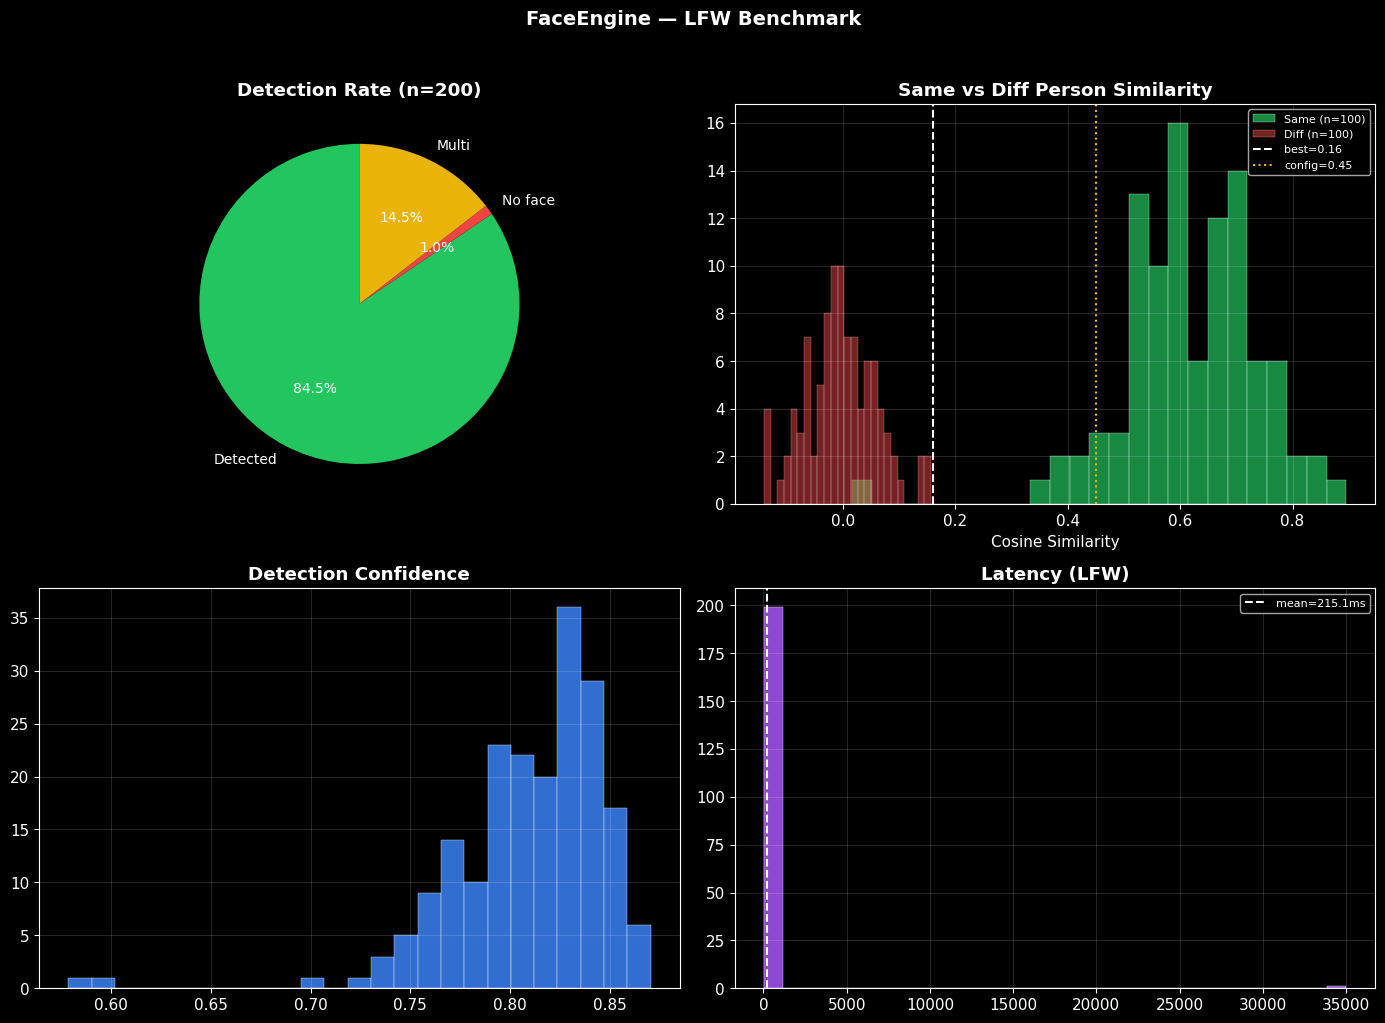

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Detection pie
axes[0,0].pie([face_acc['detected'],face_acc['no_face'],face_acc['multi']],
              labels=['Detected','No face','Multi'], colors=[C['green'],C['red'],C['yellow']],
              autopct='%1.1f%%', startangle=90, textprops={'fontsize':10})
axes[0,0].set_title(f'Detection Rate (n={tot})', fontweight='bold')

# 2) Same vs Diff similarity
axes[0,1].hist(same_sims, bins=25, color=C['green'], alpha=0.7,
               label=f'Same (n={len(same_sims)})', edgecolor='white', linewidth=0.3)
axes[0,1].hist(diff_sims, bins=25, color=C['red'], alpha=0.5,
               label=f'Diff (n={len(diff_sims)})', edgecolor='white', linewidth=0.3)
axes[0,1].axvline(best_thr, color='white', linestyle='--', label=f'best={best_thr:.2f}')
axes[0,1].axvline(0.45, color=C['yellow'], linestyle=':', label='config=0.45')
axes[0,1].set_title('Same vs Diff Person Similarity', fontweight='bold')
axes[0,1].set_xlabel('Cosine Similarity'); axes[0,1].legend(fontsize=8)

# 3) Confidence
if face_acc['confs']:
    axes[1,0].hist(face_acc['confs'], bins=25, color=C['blue'], alpha=0.85, edgecolor='white', linewidth=0.3)
    axes[1,0].set_title('Detection Confidence', fontweight='bold')

# 4) Latency
if face_acc['times_ms']:
    t_arr = np.array(face_acc['times_ms'])
    axes[1,1].hist(t_arr, bins=30, color=C['purple'], alpha=0.85, edgecolor='white', linewidth=0.3)
    axes[1,1].axvline(t_arr.mean(), color='white', linestyle='--', label=f'mean={t_arr.mean():.1f}ms')
    axes[1,1].set_title('Latency (LFW)', fontweight='bold'); axes[1,1].legend(fontsize=8)

plt.suptitle('FaceEngine — LFW Benchmark', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/tmp/bench_face.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 4. ParkingDB — pgvector (Real Embeddings from LFW)

In [12]:
from database import ParkingDB, DIM
import yaml

with open(str(PROJECT_DIR / 'config.yaml'), 'r', encoding='utf-8') as f:
    cfg = yaml.safe_load(f)
dcfg = cfg['database']
db = ParkingDB(host=dcfg['host'], port=dcfg['port'], dbname=dcfg['dbname'],
               user=dcfg['user'], password=dcfg['password'], max_cap=dcfg['max_capacity'])
print(f'DB stats: {db.stats()}')

# Collect real embeddings
print('Collecting LFW embeddings...')
real_embs = []
for p in random.sample(lfw_images, min(600, len(lfw_images))):
    img = cv2.imread(p)
    if img is None: continue
    faces = face_eng(img)
    if faces:
        real_embs.append(max(faces, key=lambda f:f['conf'])['embedding'])
    if len(real_embs) >= 500: break
print(f'Got {len(real_embs)} embeddings')

DB stats: {'current': 2, 'capacity': 500, 'pct': 0.4}
Got 500 embeddings


In [13]:
DB_SIZES = [10, 50, 100, 200, 500]
db_search_stats, db_insert_stats = [], []

for n in DB_SIZES:
    if n > len(real_embs):
        print(f'  Skip n={n}'); continue
    
    with db._conn() as conn:
        conn.cursor().execute("DELETE FROM active WHERE plate LIKE 'BM_%'")
    
    ids = []
    t0 = time.perf_counter()
    for i in range(n):
        r = db.entry(f'BM_{i:04d}', real_embs[i], 0.9, 0.8)
        if r > 0: ids.append(r)
    t_ins = (time.perf_counter()-t0)*1000
    db_insert_stats.append({'n':n, 'total_ms':t_ins, 'per_ms':t_ins/max(len(ids),1)})
    
    q = real_embs[min(n, len(real_embs)-1)]
    s = bench(lambda: db.match_exit(q, 0.3), n=min(N_BENCH,200), warmup=3, label=f'Search n={len(ids)}')
    db_search_stats.append(s)
    
    for rid in ids: db.exit(rid, 0.5)

print('\n=== Insert ===')
for s in db_insert_stats:
    print(f'  n={s["n"]:4d}  per_record={s["per_ms"]:.2f}ms')

  Search n=10                     avg=   8.43ms  p95=   9.59ms  fps= 118.6
  Search n=50                     avg=   9.10ms  p95=   9.73ms  fps= 109.9
  Search n=100                    avg=   9.15ms  p95=   9.31ms  fps= 109.3
  Search n=200                    avg=   9.18ms  p95=   9.35ms  fps= 108.9
  Search n=498                    avg=   9.38ms  p95=  13.06ms  fps= 106.6

=== Insert ===
  n=  10  per_record=11.87ms
  n=  50  per_record=7.57ms
  n= 100  per_record=7.23ms
  n= 200  per_record=7.18ms
  n= 500  per_record=7.18ms


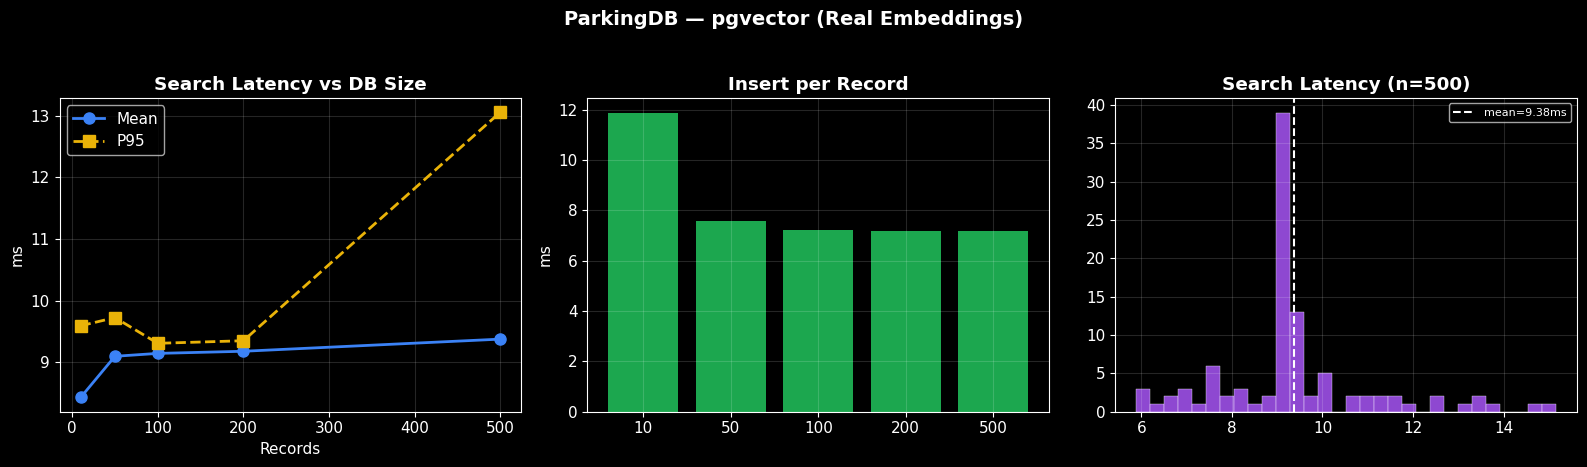

In [14]:
if db_search_stats:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    ns = [s['n'] for s in db_insert_stats]

    axes[0].plot(ns[:len(db_search_stats)], [s['mean'] for s in db_search_stats], 'o-',
                 color=C['blue'], label='Mean', linewidth=2, markersize=8)
    axes[0].plot(ns[:len(db_search_stats)], [s['p95'] for s in db_search_stats], 's--',
                 color=C['yellow'], label='P95', linewidth=2, markersize=8)
    axes[0].set_xlabel('Records'); axes[0].set_ylabel('ms')
    axes[0].set_title('Search Latency vs DB Size', fontweight='bold'); axes[0].legend()

    axes[1].bar(range(len(ns)), [s['per_ms'] for s in db_insert_stats],
                tick_label=[str(n) for n in ns], color=C['green'], alpha=0.85)
    axes[1].set_title('Insert per Record', fontweight='bold'); axes[1].set_ylabel('ms')

    last = db_search_stats[-1]
    axes[2].hist(last['raw'], bins=30, color=C['purple'], alpha=0.85, edgecolor='white', linewidth=0.3)
    axes[2].axvline(last['mean'], color='white', linestyle='--', label=f'mean={last["mean"]:.2f}ms')
    axes[2].set_title(f'Search Latency (n={ns[-1]})', fontweight='bold'); axes[2].legend(fontsize=8)

    plt.suptitle('ParkingDB — pgvector (Real Embeddings)', fontsize=14, fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.savefig('/tmp/bench_db.png', dpi=120, bbox_inches='tight')
    plt.show()

---
## 5. End-to-End + Summary

In [ ]:
# ── E2E: Det → OCR → Validate → Face → DB ──

if HAS_DET:
    e2e_plates = sorted(glob.glob(os.path.join(DET_IMAGES_DIR,'*.jpg'))+
                        glob.glob(os.path.join(DET_IMAGES_DIR,'*.png')))[:100]
else:
    e2e_plates = None

e2e_faces = random.sample(lfw_images, min(100, len(lfw_images)))

# Seed DB
with db._conn() as conn:
    conn.cursor().execute("DELETE FROM active WHERE plate LIKE 'E2E_%'")
for i in range(min(50, len(real_embs))):
    db.entry(f'E2E_{i:03d}', real_embs[i], 0.9, 0.8)

e2e = {'plate_det':[], 'ocr':[], 'validate':[], 'face_det':[], 'quality':[], 'db_search':[], 'total':[]}
N_E2E = min(100, len(e2e_faces))

print(f'Running {N_E2E} E2E iterations...')
for i in range(N_E2E):
    tt = time.perf_counter()

    if e2e_plates:
        pimg = cv2.imread(e2e_plates[i % len(e2e_plates)])
    else:
        pimg = np.random.randint(0,255,(1280,1280,3), dtype=np.uint8)  # square cho TRT

    t0=time.perf_counter(); dets=plate_det(pad_to_square(pimg)); e2e['plate_det'].append((time.perf_counter()-t0)*1000)

    if dets:
        best=max(dets,key=lambda d:d['conf'])
        x1,y1,x2,y2=best['bbox']; h,w=pimg.shape[:2]
        bw,bh=x2-x1,y2-y1; mx,my=max(10,int(bw*0.08)),max(8,int(bh*0.12))
        crop=pimg[max(0,y1-my):min(h,y2+my),max(0,x1-mx):min(w,x2+mx)]
        t0=time.perf_counter(); raw,_=plate_ocr(crop); e2e['ocr'].append((time.perf_counter()-t0)*1000)
        t0=time.perf_counter(); validator(raw); e2e['validate'].append((time.perf_counter()-t0)*1000)

    fimg = cv2.imread(e2e_faces[i % len(e2e_faces)])
    if fimg is not None:
        t0=time.perf_counter(); faces=face_eng(fimg); e2e['face_det'].append((time.perf_counter()-t0)*1000)
        if faces:
            bf=max(faces,key=lambda f:f['conf'])
            t0=time.perf_counter(); FaceEngine.quality_score(fimg,bf['bbox']); e2e['quality'].append((time.perf_counter()-t0)*1000)
            t0=time.perf_counter(); db.match_exit(bf['embedding'],0.45); e2e['db_search'].append((time.perf_counter()-t0)*1000)

    e2e['total'].append((time.perf_counter()-tt)*1000)

with db._conn() as conn:
    conn.cursor().execute("DELETE FROM active WHERE plate LIKE 'E2E_%'")

total_avg = np.mean(e2e['total'])
print(f'\n{"Step":15s} {"Avg":>8s} {"P95":>8s} {"% total":>8s}')
print('-'*42)
for step in ['plate_det','ocr','validate','face_det','quality','db_search','total']:
    if not e2e[step]: continue
    a=np.array(e2e[step])
    pct = 100*a.mean()/total_avg if step!='total' else 100
    print(f'{step:15s} {a.mean():7.1f}ms {np.percentile(a,95):7.1f}ms {pct:7.1f}%')
print(f'\n→ E2E FPS: {1000/total_avg:.1f}')

Running 100 E2E iterations...


NameError: name 'plate_det' is not defined

: 

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

steps = ['plate_det','ocr','validate','face_det','quality','db_search']
snames = ['Plate Det','OCR','Validate','Face Det','Quality','DB Search']
scols = [C['blue'],C['green'],C['cyan'],C['purple'],C['orange'],C['pink']]
avgs = [np.mean(e2e[s]) if e2e[s] else 0 for s in steps]

left=0
for a,nm,co in zip(avgs,snames,scols):
    axes[0].barh(0, a, left=left, height=0.4, color=co, label=f'{nm}: {a:.1f}ms', alpha=0.9)
    if a>2: axes[0].text(left+a/2, 0, f'{a:.1f}', ha='center', va='center', fontsize=9, fontweight='bold')
    left+=a
axes[0].set_yticks([]); axes[0].set_xlabel('ms')
axes[0].set_title(f'Breakdown (total: {sum(avgs):.1f}ms)', fontweight='bold')
axes[0].legend(loc='upper right', fontsize=7)

nz = [(n,a,c) for n,a,c in zip(snames,avgs,scols) if a>0]
if nz:
    pn,pa,pc = zip(*nz)
    axes[1].pie(pa, labels=pn, colors=pc, autopct='%1.1f%%', startangle=90, textprops={'fontsize':9})
    axes[1].set_title('Time Distribution', fontweight='bold')

ta = np.array(e2e['total'])
axes[2].plot(ta, color=C['blue'], alpha=0.5, linewidth=0.8)
w=min(10,len(ta))
if w>1:
    r=np.convolve(ta,np.ones(w)/w,mode='valid')
    axes[2].plot(range(w-1,len(ta)),r,color=C['green'],linewidth=2,label=f'Rolling({w})')
axes[2].axhline(ta.mean(),color='white',linestyle='--',alpha=0.5,label=f'Mean: {ta.mean():.1f}ms')
axes[2].set_xlabel('Frame'); axes[2].set_ylabel('ms')
axes[2].set_title('Per-Frame Latency', fontweight='bold'); axes[2].legend(fontsize=8)

plt.suptitle('End-to-End Pipeline', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('/tmp/bench_e2e.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# ── Overall Summary ──
all_stats = []
if det_latency: all_stats.append(det_latency[0])  # 640x640   # 720p
if len(ocr_latency)>=2: all_stats.append(ocr_latency[1])   # 160x48
if len(face_latency)>=1: all_stats.append(face_latency[0]) # 640x480
if db_search_stats: all_stats.append(db_search_stats[-1])

print('='*65)
print('  SUMMARY')
print('='*65)
print(f'{"Component":30s} {"Mean":>8s} {"P95":>8s} {"FPS":>8s}')
print('-'*65)
for s in all_stats:
    print(f'{s["label"]:30s} {s["mean"]:7.2f}ms {s["p95"]:7.2f}ms {s["fps"]:7.1f}')
if e2e['total']:
    t=np.array(e2e['total'])
    print(f'{"End-to-End":30s} {t.mean():7.2f}ms {np.percentile(t,95):7.2f}ms {1000/t.mean():7.1f}')
print('='*65)

In [ ]:
if all_stats:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Bar comparison
    labels=[s['label'] for s in all_stats]; means=[s['mean'] for s in all_stats]; p95s=[s['p95'] for s in all_stats]
    x=np.arange(len(labels)); w=0.3
    axes[0].bar(x-w/2,means,w,label='Mean',color=C['blue'],alpha=0.9)
    axes[0].bar(x+w/2,p95s,w,label='P95',color=C['yellow'],alpha=0.9)
    for i,v in enumerate(means): axes[0].text(i-w/2,v+0.3,f'{v:.1f}',ha='center',fontsize=9)
    axes[0].set_xticks(x); axes[0].set_xticklabels(labels,rotation=15,ha='right',fontsize=9)
    axes[0].set_ylabel('ms'); axes[0].set_title('Latency Comparison', fontweight='bold'); axes[0].legend()

    # Bottleneck Pareto
    total=sum(means); pcts=[m/total*100 for m in means]
    idx=np.argsort(means)[::-1]
    sl=[labels[i] for i in idx]; sm=[means[i] for i in idx]; sp=[pcts[i] for i in idx]
    bc=[C['red'] if p>40 else C['yellow'] if p>20 else C['green'] for p in sp]
    bars=axes[1].barh(sl,sm,color=bc,alpha=0.85,height=0.5)
    cum=np.cumsum(sm); ax2=axes[1].twiny()
    ax2.plot(cum/total*100,range(len(sl)),'wo-',markersize=6,linewidth=2,alpha=0.8)
    ax2.set_xlim(0,105); ax2.set_xlabel('Cumulative %',color='white',alpha=0.6)
    for b,m,p in zip(bars,sm,sp):
        axes[1].text(b.get_width()+0.3,b.get_y()+b.get_height()/2,
                     f'{m:.1f}ms ({p:.0f}%)',va='center',fontsize=10,fontweight='bold')
    axes[1].set_xlabel('ms'); axes[1].set_title('Bottleneck (Pareto)', fontweight='bold')
    axes[1].legend(handles=[
        mpatches.Patch(color=C['red'],label='>40%'),
        mpatches.Patch(color=C['yellow'],label='>20%'),
        mpatches.Patch(color=C['green'],label='<20%'),
    ], loc='lower right', fontsize=8)

    plt.suptitle('Overall Performance', fontsize=14, fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.savefig('/tmp/bench_summary.png', dpi=120, bbox_inches='tight')
    plt.show()

In [ ]:
db.close()
print('\n✅ Benchmark complete!')
for f in sorted(glob.glob('/tmp/bench_*.png')):
    print(f'  {f} ({os.path.getsize(f)/1024:.0f}KB)')